In [2]:
import os
import torch

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

if not torch.cuda.is_available():
    raise RuntimeError('GPU tidak tersedia untuk eksekusi notebook ini')

device = torch.device('cuda')
print('Using device:', device)
print('GPU:', torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 4090


In [ ]:
# PyTorch reproducibility seed cell
import os
import random
import numpy as np
import torch

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print('PyTorch seed diterapkan: ' + str(SEED))


# Ashoka - Scrambled AI
## Experiment Classification with hybrid CNN and C-Swin

1. Daffa Dians Ramadhan - 1402023016
2. Dina Amaliah - 1402023020
3. Sultan Hafidzh Polihito - 1402023067


Outline:  

1. Data Understanding
2. Data Preparation
3. Modeling
4. Training
5. Model Evaluation
6. Deployment

#1. Data Understanding

##1.1 Import libraries

In [3]:
import os
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg16, VGG16_Weights
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc

##1.2 Load Dataset Path

In [4]:
# Menentukan device otomatis
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Menjalankan notebook pada device: {device}")

[INFO] Menjalankan notebook pada device: cuda


In [5]:
base_dir = os.getcwd()
normal_path = os.path.join(base_dir, "dataset_image_normal")
buried_path = os.path.join(base_dir, "dataset_image_buried")

normal_images = [os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.endswith(('jpg','png','jpeg','JPG','PNG','JPEG'))]
buried_images = [os.path.join(buried_path, f) for f in os.listdir(buried_path) if f.endswith(('jpg','png','jpeg','JPG','PNG','JPEG'))]

print("Total Normal images:", len(normal_images))
print("Total Buried images:", len(buried_images))

Total Normal images: 91
Total Buried images: 110


##1.3 Example Image

In [ ]:
def show_samples(image_paths, title, n=5):
    plt.figure(figsize=(15, 3))
    for i in range(n):
        img = Image.open(image_paths[i]).convert('RGB')
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"{title} {i+1}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(normal_images, "Normal")
show_samples(buried_images, "Buried")

##1.4 Visualisasi Data

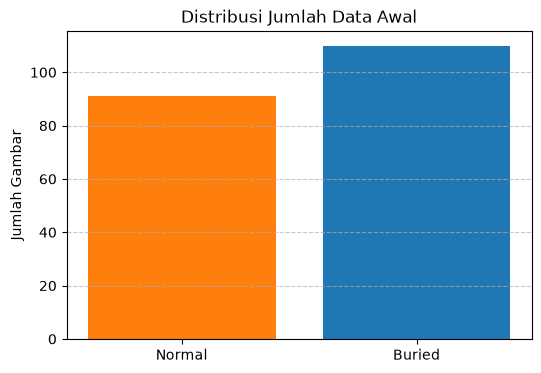

In [7]:
plt.figure(figsize=(6, 4))
plt.bar(['Normal', 'Buried'], [len(normal_images), len(buried_images)], color=['#ff7f0e', '#1f77b4'])
plt.title("Distribusi Jumlah Data Awal")
plt.ylabel("Jumlah Gambar")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#2. Data Preparation

In [8]:
class CustomBinaryDataset(Dataset):
    def __init__(self, normal_paths, buried_paths, transform=None):
        self.image_paths = normal_paths + buried_paths
        self.labels = [0] * len(normal_paths) + [1] * len(buried_paths)
        self.transform = transform
        self.classes = ['Normal', 'Buried']

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

# Ukuran input disesuaikan ke 112 sesuai arsitektur C-Swin
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Buat Dataset & Split 70:15:15
full_dataset = CustomBinaryDataset(normal_images, buried_images)
total = len(full_dataset)
train_sz = int(0.70 * total)
val_sz = int(0.15 * total)
test_sz = total - train_sz - val_sz

generator = torch.Generator().manual_seed(42)
train_set, val_set, test_set = random_split(full_dataset, [train_sz, val_sz, test_sz], generator=generator)

# Wrapper buat bedain transformasi data train & val/test
class DatasetWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img_path = self.subset.dataset.image_paths[self.subset.indices[idx]]
        label = self.subset.dataset.labels[self.subset.indices[idx]]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

train_loader = DataLoader(DatasetWrapper(train_set, train_transforms), batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(DatasetWrapper(val_set, val_test_transforms), batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(DatasetWrapper(test_set, val_test_transforms), batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train: 140 | Val: 30 | Test: 31


#3. Modeling

In [9]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()
        weights = VGG16_Weights.DEFAULT
        vgg = vgg16(weights=weights)
        self.features = vgg.features

        self.conv1x1 = nn.Conv2d(512, 256, kernel_size=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        return self.relu(self.conv1x1(x))

class SGLU(nn.Module):
    def __init__(self, units):
        super(SGLU, self).__init__()
        self.wg = nn.Linear(units, units)
        self.wx = nn.Linear(units, units)
        self.w2 = nn.Linear(units, units)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        zg = self.wg(x)
        zx = self.wx(x)
        y = (zx * self.sigmoid(zx)) * zg
        return self.w2(y)

class SwinTransformerBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=4):
        super(SwinTransformerBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = SGLU(embed_dim)
    def forward(self, x):
        norm_x = self.norm1(x)
        attn_out, _ = self.attn(norm_x, norm_x, norm_x)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class CSwinModel(nn.Module):
    def __init__(self, num_classes=1):
        super(CSwinModel, self).__init__()
        self.cnn = CNNFeatureExtractor()
        self.swin = SwinTransformerBlock(embed_dim=256, num_heads=4)
        self.fc = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.cnn(x)
        batch_size, channels, h, w = x.size()
        x = x.view(batch_size, channels, h * w).transpose(1, 2)
        x = self.swin(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)

#4. Training

In [10]:
EPOCHS = 100
LEARNING_RATE = 1e-4
PATIENCE = 30

def compile_and_train(model, train_loader, val_loader, device):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        # TRAINING
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).float()

            optimizer.zero_grad()
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = (outputs >= 0.0).float()
            total_train += labels.size(0)
            correct_train += (preds == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        # VALIDATION
        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).float()
                outputs = model(images).squeeze(1)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                preds = (outputs >= 0.0).float()
                total_val += labels.size(0)
                correct_val += (preds == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val


        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch [{epoch+1}/{EPOCHS}] -> "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")


        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print(f" => [SAVED] Model terbaik: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            print(f" => Tetap/Tidak membaik selama {patience_counter}/{PATIENCE} epoch.")

        if patience_counter >= PATIENCE:
            print(f"\nSelesai di epoch ke-{epoch+1}.")
            break

    return history

#Inisialisasi Model ke Device tujuan
print("build arsitektur model")
model = CSwinModel(num_classes=1).to(device)

#Jalankan Proses Training
print("running proses training")
history = compile_and_train(model, train_loader, val_loader, device)

build arsitektur model


running proses training


Epoch [1/100] -> Train Loss: 0.6943, Train Acc: 0.5000 | Val Loss: 0.5767, Val Acc: 0.6333
 => [SAVED] Model terbaik: 0.5767


Epoch [2/100] -> Train Loss: 0.5731, Train Acc: 0.6786 | Val Loss: 0.5362, Val Acc: 0.8333
 => [SAVED] Model terbaik: 0.5362


Epoch [3/100] -> Train Loss: 0.4190, Train Acc: 0.8143 | Val Loss: 0.2932, Val Acc: 0.8667
 => [SAVED] Model terbaik: 0.2932


...

Epoch [38/100] -> Train Loss: 0.0005, Train Acc: 1.0000 | Val Loss: 0.4303, Val Acc: 0.8333
 => Tetap/Tidak membaik selama 26/30 epoch.


Epoch [39/100] -> Train Loss: 0.0007, Train Acc: 1.0000 | Val Loss: 0.4491, Val Acc: 0.8667
 => Tetap/Tidak membaik selama 27/30 epoch.


Epoch [40/100] -> Train Loss: 0.0029, Train Acc: 1.0000 | Val Loss: 0.3585, Val Acc: 0.9000
 => Tetap/Tidak membaik selama 28/30 epoch.


Epoch [41/100] -> Train Loss: 0.0010, Train Acc: 1.0000 | Val Loss: 0.4887, Val Acc: 0.9000
 => Tetap/Tidak membaik selama 29/30 epoch.


Epoch [42/100] -> Train Loss: 0.0036, Train Acc: 1.0000 | Val Loss: 0.3354, Val Acc: 0.9000
 => Tetap/Tidak membaik selama 30/30 epoch.

Selesai di epoch ke-42.


#5. Model Evaluation

##5.1 Metrics

In [11]:
def evaluate_model(model, test_loader, device):
    print("Melakukan prediksi pada seluruh data test.")
    
    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    
    all_labels, all_probs = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images).squeeze(1) 
            probs = torch.sigmoid(outputs)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            
    y_true = np.array(all_labels)
    y_probs = np.array(all_probs)
    y_pred = (y_probs >= 0.5).astype(int)
    
    class_names = ['Normal', 'Buried']

    print("\n================== Classification Report ==================")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    print("===================== Confusion Matrix =====================")
    print(confusion_matrix(y_true, y_pred))
    print("============================================================")
    
    return y_true, y_probs


y_true, y_probs = evaluate_model(model, test_loader, device)

Melakukan prediksi pada seluruh data test.



================== Classification Report ==================
              precision    recall  f1-score   support

      Normal     0.9474    0.9000    0.9231        20
      Buried     0.8333    0.9091    0.8696        11

    accuracy                         0.9032        31
   macro avg     0.8904    0.9045    0.8963        31
weighted avg     0.9069    0.9032    0.9041        31

===================== Confusion Matrix =====================
[[18  2]
 [ 1 10]]


##5.2 Grafik Visualization

Grafik riwayat akurasi training


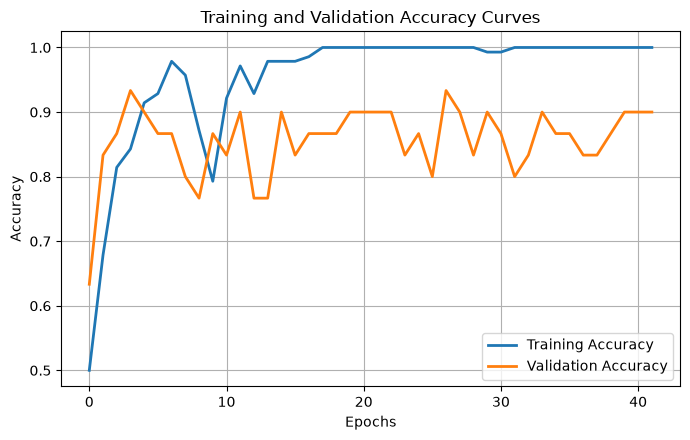


Heatmap confusion matrix


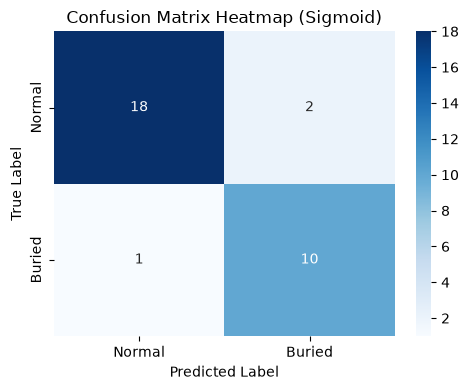


Precision-Recall dan ROC-AUC Curve


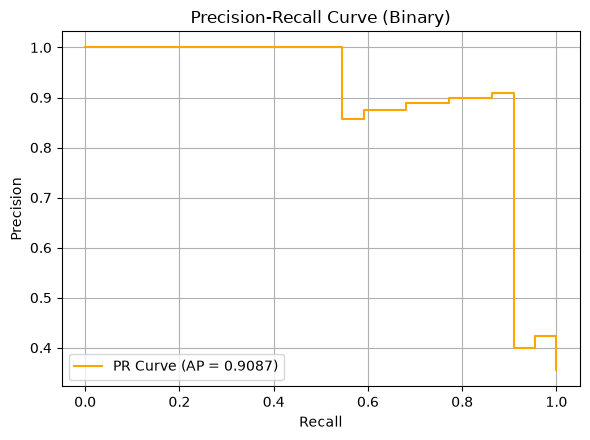

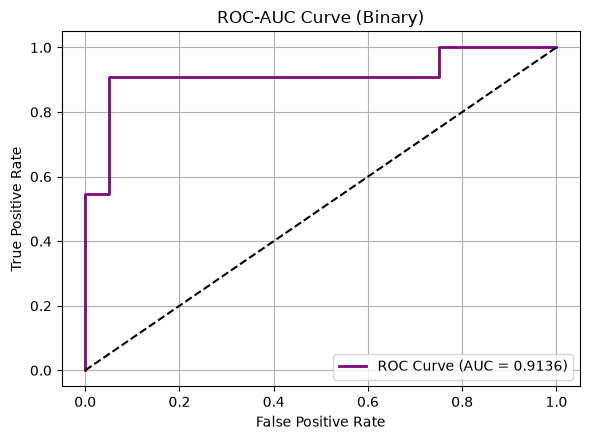

In [12]:
def plot_training_history(history):
    """Fungsi menggambar Kurva Akurasi Selama Training"""
    epochs = len(history['train_acc'])
    plt.figure(figsize=(7, 4.5))
    plt.plot(range(epochs), history['train_acc'], label='Training Accuracy', linewidth=2)
    plt.plot(range(epochs), history['val_acc'], label='Validation Accuracy', linewidth=2)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Curves')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_heatmap(all_labels, all_probs, class_names):
    """Fungsi menampilkan Heatmap Confusion Matrix"""
    all_preds = (all_probs >= 0.5).astype(int)
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix Heatmap (Sigmoid)')
    plt.tight_layout()
    plt.show()

def plot_curves(all_labels, all_probs):
    """Fungsi menampilkan grafik Precision-Recall Curve dan ROC-AUC Curve"""
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    ap = average_precision_score(all_labels, all_probs)

    plt.figure(figsize=(6, 4.5))
    plt.step(recall, precision, where='mid', color='orange', label=f'PR Curve (AP = {ap:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (Binary)')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ROC-AUC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    score_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4.5))
    plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC Curve (AUC = {score_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='black', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve (Binary)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Evaluasi pada data test
class_names = ['Normal', 'Buried']

# Ambil prediksi dari model
with torch.no_grad():
    y_true = []
    y_probs = []
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        y_true.extend(labels.numpy())
        y_probs.extend(probs)

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

print("Grafik riwayat akurasi training")
plot_training_history(history)

print("\nHeatmap confusion matrix")
plot_heatmap(y_true, y_probs, class_names)

print("\nPrecision-Recall dan ROC-AUC Curve")
plot_curves(y_true, y_probs)

In [14]:
# Per-run metric summary (accuracy, precision, recall/sensitivity, f1, specificity, ROC AUC)
import numpy as np
try:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
except Exception as e:
    print('sklearn not available:', e)

try:
    y_true_arr = np.array([int(x) for x in y_true])
    y_probs_arr = np.array(y_probs).reshape(-1)
    y_pred = (y_probs_arr >= 0.5).astype(int)
except Exception as e:
    print('y_true/y_probs not available:', e)
else:
    acc = accuracy_score(y_true_arr, y_pred)
    precision_macro = precision_score(y_true_arr, y_pred, average='macro')
    precision_weighted = precision_score(y_true_arr, y_pred, average='weighted')
    recall_macro = recall_score(y_true_arr, y_pred, average='macro')
    f1_macro = f1_score(y_true_arr, y_pred, average='macro')
    f1_weighted = f1_score(y_true_arr, y_pred, average='weighted')
    # specificity
    cm = None
    try:
        cm = confusion_matrix(y_true_arr, y_pred)
    except Exception:
        pass
    specificity = None
    if cm is not None and cm.shape==(2,2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn+fp)>0 else None
    # roc auc (if probabilities)
    roc_auc = None
    try:
        roc_auc = roc_auc_score(y_true_arr, y_probs_arr)
    except Exception:
        pass
    # Print a machine-parseable summary line and human lines
    print(f"METRIC_SUMMARY: accuracy={acc:.4f} precision_macro={precision_macro:.4f} precision_weighted={precision_weighted:.4f} recall_macro={recall_macro:.4f} f1_macro={f1_macro:.4f} f1_weighted={f1_weighted:.4f} specificity={'' if specificity is None else f'{specificity:.4f}'} roc_auc={'' if roc_auc is None else f'{roc_auc:.4f}'}")
    print('--- Per-run metrics ---')
    print('Accuracy:', acc)
    print('Precision (macro):', precision_macro)
    print('Precision (weighted):', precision_weighted)
    print('Recall (macro):', recall_macro)
    print('F1 (macro):', f1_macro)
    print('F1 (weighted):', f1_weighted)
    print('Specificity:', specificity)
    print('ROC AUC:', roc_auc)


METRIC_SUMMARY: accuracy=0.9032 precision_macro=0.8904 precision_weighted=0.9069 recall_macro=0.9045 f1_macro=0.8963 f1_weighted=0.9041 specificity=0.9000 roc_auc=0.9136
--- Per-run metrics ---
Accuracy: 0.9032258064516129
Precision (macro): 0.8903508771929824
Precision (weighted): 0.9069043576683644
Recall (macro): 0.9045454545454545
F1 (macro): 0.8963210702341138
F1 (weighted): 0.9040888984788004
Specificity: 0.9
ROC AUC: 0.9136363636363636
